<a href="https://colab.research.google.com/github/the-tusar/COMP-G/blob/main/W1_data_acquisition_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# CELL 1: Setup and Load Data
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Direct link to public Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset successfully loaded!")
print("Initial Shape:", df.shape)
df.head()


Dataset successfully loaded!
Initial Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# ==========================================
# CELL 2: Initial Exploration (EDA)
# ==========================================
# Check data types and non-null counts
print("--- INFO ---")
df.info()

print("\n--- SUMMARY STATISTICS ---")
df.describe()


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- SUMMARY STATISTICS ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
# ==========================================
# CELL 3: Check Duplicates and Missing Values
# ==========================================
print("Duplicate rows:", df.duplicated().sum())

print("\nMissing values per column:")
print(df.isnull().sum())


Duplicate rows: 0

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [4]:
# ==========================================
# CELL 4: Data Cleaning (Null Values & Columns)
# ==========================================
# 1. Drop 'Cabin' because >75% values are missing
df_clean = df.drop(columns=['Cabin'])

# 2. Impute 'Age' missing values with the median
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())

# 3. Impute 'Embarked' missing values with the mode
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

# 4. Remove unneeded identifier columns for general analysis
df_clean = df_clean.drop(columns=['PassengerId', 'Ticket', 'Name'])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())


Missing values after cleaning:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


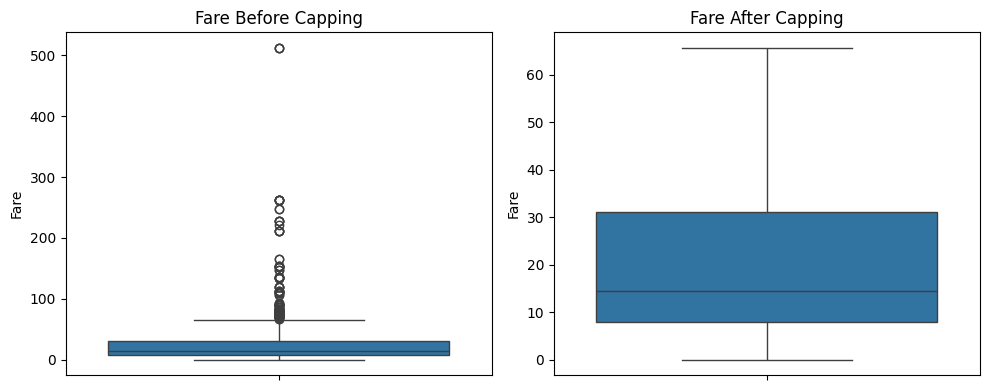

In [5]:
# ==========================================
# CELL 5: Outlier Detection & Capping (IQR)
# ==========================================
# Boxplot before outlier handling
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_clean['Fare'])
plt.title("Fare Before Capping")

# Cap 'Fare' using IQR method
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean['Fare'] = np.clip(df_clean['Fare'], lower_bound, upper_bound)

# Boxplot after outlier handling
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['Fare'])
plt.title("Fare After Capping")
plt.tight_layout()
plt.show()


In [6]:
# ==========================================
# CELL 6: Save the Cleaned Dataset
# ==========================================
df_clean.to_csv("cleaned_titanic_dataset.csv", index=False)
print("Cleaned file saved successfully as 'cleaned_titanic_dataset.csv'")
print("Final Shape:", df_clean.shape)


Cleaned file saved successfully as 'cleaned_titanic_dataset.csv'
Final Shape: (891, 8)
